# Mobile Price Prediction - Multi-Class Classification

## Course: Introduction to Data Science  
## Assignment: Mobile Price Prediction  

### Group Details:
- **Group No:** 2  
- **Member 1:** Moulik Patra: 2025mt03009
- **Member 2:** Vedpathak Yuvraj Vijay: 2025mt03141
- **Member 3:** Ajeet Kumar Yadav: 2025mt03083

### Dataset:
Mobile Price Prediction Dataset (Train & Test)

### Objective:
To build and evaluate multi-class classification models to predict the price range (0–3) of mobile phones based on their technical specifications.

---

## 1. Import Libraries and Dataset

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
df = pd.read_csv("Mobile_Price_Prediction_train.csv")

# Display first 5 rows
df.head()

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,1,707,No,2.1,Yes,2,0,25,0.8,Med,...,495,574,3838,9,2,7,1,No,Yes,3
1,2,1218,No,1.8,Yes,1,1,14,0.5,Med,...,229,616,398,17,0,5,1,No,No,0
2,3,1986,No,0.5,No,7,0,51,0.4,Low,...,342,774,3165,5,0,13,1,No,No,3
3,4,1290,No,0.5,No,0,0,3,0.1,Med,...,600,1109,1214,9,8,15,0,Yes,Yes,1
4,5,1135,Yes,2.8,Yes,9,0,43,0.4,Med,...,690,1589,3204,18,13,6,1,No,No,3


**The dataset has been successfully loaded and the target variable `price_range` has been identified.**

## 2. Data and Data Models

In [2]:
# Display shape of the dataset
print("Shape of the dataset:", df.shape)

# Display feature names / column names
print("\nFeature Names:")
print(df.columns.tolist())

# Display data types of all columns
print("\nData Types:")
print(df.dtypes)

# Display first 2 rows for sanity check
print("\nFirst 2 Rows of the Dataset:")
display(df.head(2))

Shape of the dataset: (2000, 22)

Feature Names:
['id', 'battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g', 'touch_screen', 'wifi', 'price_range']

Data Types:
id                 int64
battery_power      int64
blue                 str
clock_speed      float64
dual_sim             str
fc                 int64
four_g             int64
int_memory         int64
m_dep            float64
mobile_wt            str
n_cores            int64
pc                 int64
px_height          int64
px_width           int64
ram                int64
sc_h               int64
sc_w               int64
talk_time          int64
three_g            int64
touch_screen         str
wifi                 str
price_range        int64
dtype: object

First 2 Rows of the Dataset:


,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,1,707,No,2.1,Yes,2,0,25,0.8,Med,...,495,574,3838,9,2,7,1,No,Yes,3
1,2,1218,No,1.8,Yes,1,1,14,0.5,Med,...,229,616,398,17,0,5,1,No,No,0


### Simple Data Pipeline for the Project

The simple data pipeline for this project consists of the following stages:

1. **Data Extraction**  
   The dataset is obtained from the provided CSV files containing the mobile phone specifications and target price range.

2. **Data Ingestion**  
   The dataset is loaded into the notebook environment using the pandas library for further analysis and model building.

3. **Data Cleaning**  
   The dataset is checked for missing values, inconsistent entries, and improper data types. Necessary cleaning steps are applied before analysis.

4. **Data Exploration**  
   The data is explored using summary statistics and visualizations to understand the distribution of features and the target variable.

5. **Data Wrangling**  
   The dataset is reorganized into a suitable structure for machine learning, including separating features and target variables.

6. **Data Versioning**  
   The original dataset files are preserved separately so that preprocessing and transformations do not overwrite the raw data, ensuring reproducibility.

7. **Data Transformation**  
   Required transformations such as encoding categorical variables and scaling numerical features are applied to prepare the data for classification models.

8. **Feature Management**  
   Relevant input features are retained, transformed, and managed properly so that they can be used effectively in model training and evaluation.

**The dataset contains 2000 records and 22 features, including the target variable `price_range`. The data types indicate a mix of numerical and categorical variables, which will require appropriate preprocessing before model training. The initial inspection confirms that the dataset is well-structured and suitable for multi-class classification. A clear data pipeline has been established to ensure systematic handling of data from ingestion to feature management.**

## 3. Data Visualization and Exploration

Statistical Summary:


,id,battery_power,clock_speed,fc,four_g,int_memory,m_dep,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,price_range
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,1238.518500,1.522250,4.309500,0.521500,32.046500,0.501750,4.520500,9.916500,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,1.500000
std,577.494589,439.418206,0.816004,4.341444,0.499662,18.145715,0.288416,2.287837,6.064315,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,1.118314
min,1.000000,501.000000,0.500000,0.000000,0.000000,2.000000,0.100000,1.000000,0.000000,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000
25%,500.750000,851.750000,0.700000,1.000000,0.000000,16.000000,0.200000,3.000000,5.000000,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.750000
50%,1000.500000,1226.000000,1.500000,3.000000,1.000000,32.000000,0.500000,4.000000,10.000000,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.500000
75%,1500.250000,1615.250000,2.200000,7.000000,1.000000,48.000000,0.800000,7.000000,15.000000,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,2.250000
max,2000.000000,1998.000000,3.000000,19.000000,1.000000,64.000000,1.000000,8.000000,20.000000,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,3.000000


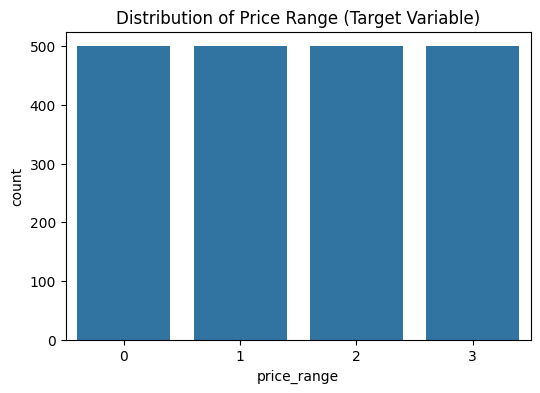

In [3]:
# Statistical Summary
print("Statistical Summary:")
display(df.describe())

# Distribution of Target Variable
plt.figure(figsize=(6,4))
sns.countplot(x='price_range', data=df)
plt.title("Distribution of Price Range (Target Variable)")
plt.show()

### Class Imbalance Observation

The distribution of the target variable `price_range` appears balanced across all four classes, indicating no significant class imbalance in the dataset.

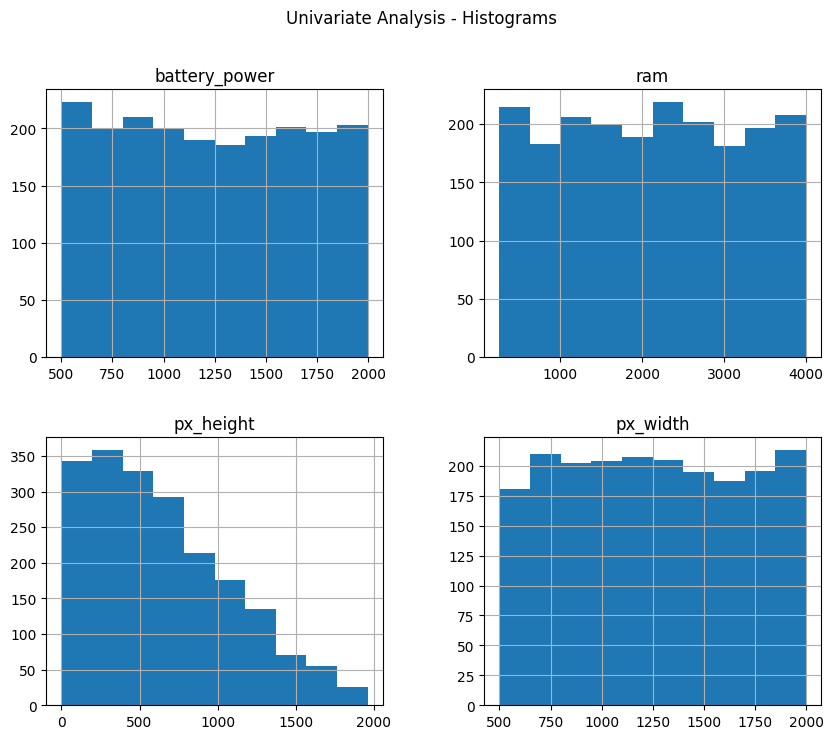

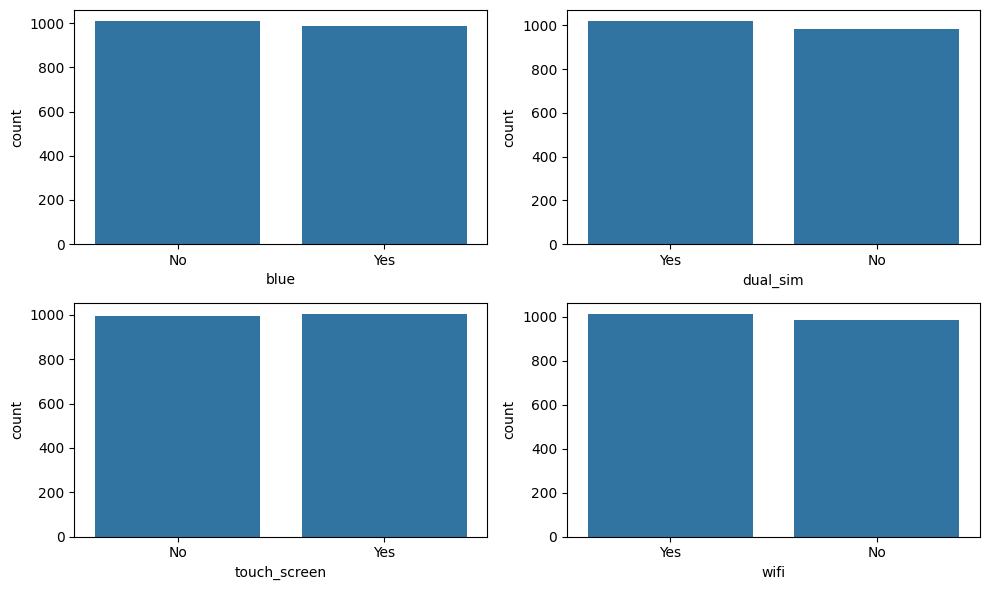

In [4]:
# Univariate Analysis - Histograms (selected important features)

df[['battery_power', 'ram', 'px_height', 'px_width']].hist(figsize=(10,8))
plt.suptitle("Univariate Analysis - Histograms")
plt.show()

# Countplots for categorical features
plt.figure(figsize=(10,6))

plt.subplot(2,2,1)
sns.countplot(x='blue', data=df)

plt.subplot(2,2,2)
sns.countplot(x='dual_sim', data=df)

plt.subplot(2,2,3)
sns.countplot(x='touch_screen', data=df)

plt.subplot(2,2,4)
sns.countplot(x='wifi', data=df)

plt.tight_layout()
plt.show()

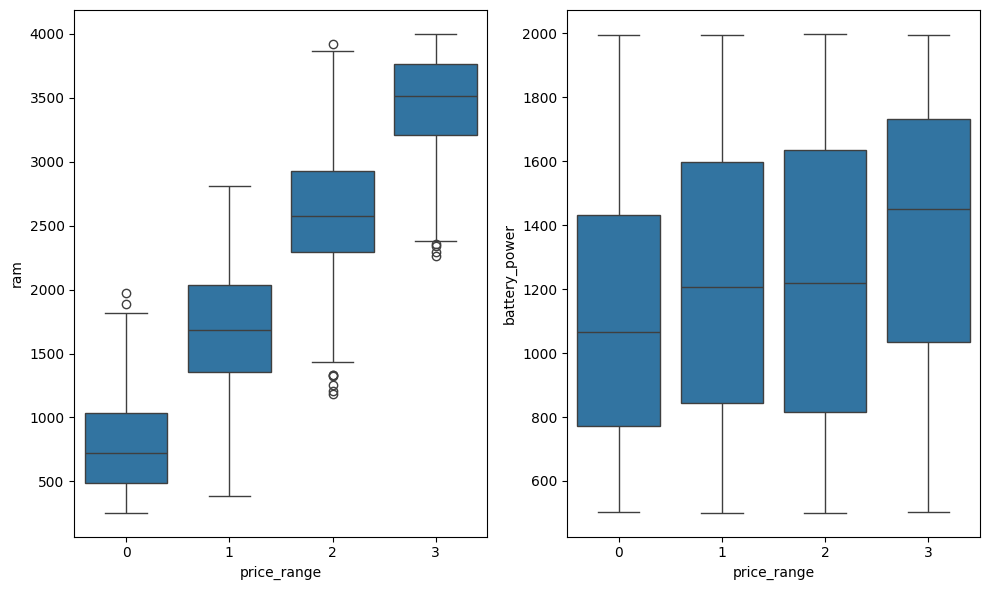

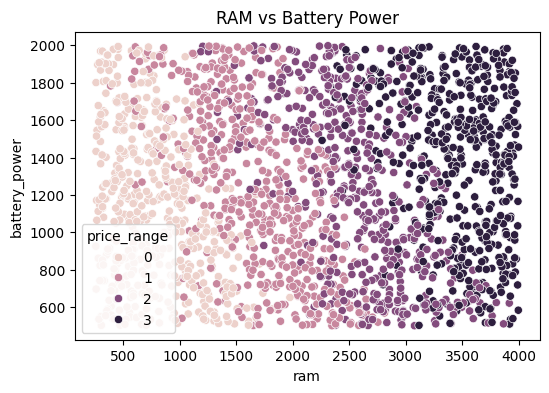

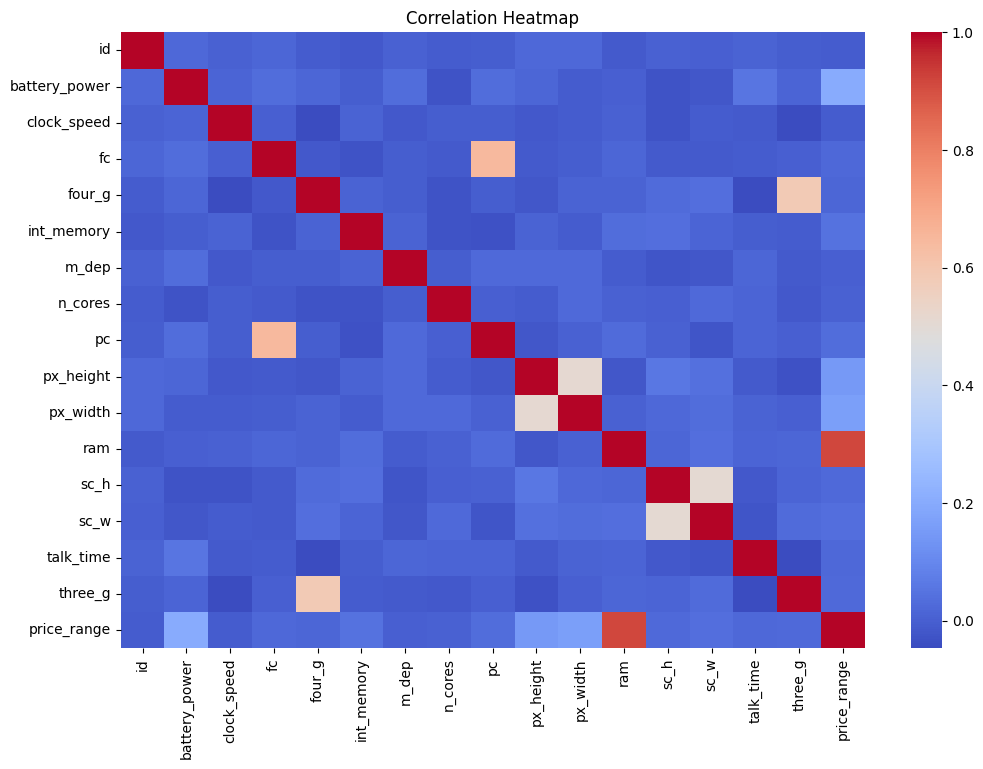

In [5]:
# Bivariate Analysis - Boxplots vs target

plt.figure(figsize=(10,6))

plt.subplot(1,2,1)
sns.boxplot(x='price_range', y='ram', data=df)

plt.subplot(1,2,2)
sns.boxplot(x='price_range', y='battery_power', data=df)

plt.tight_layout()
plt.show()

# Scatterplot
plt.figure(figsize=(6,4))
sns.scatterplot(x='ram', y='battery_power', hue='price_range', data=df)
plt.title("RAM vs Battery Power")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Observations from Data Visualization and Exploration

1. **Class Distribution:**
   - The target variable `price_range` is evenly distributed across all four classes (0, 1, 2, 3).
   - This indicates **no class imbalance**, which is beneficial for model training.

2. **Univariate Analysis:**
   - Features like `battery_power`, `ram`, and `px_width` show relatively uniform distributions.
   - `px_height` shows a slightly skewed distribution with more values in the lower range.
   - Binary features such as `blue`, `dual_sim`, `touch_screen`, and `wifi` are almost evenly distributed between Yes/No.

3. **Bivariate Analysis:**
   - **RAM vs Price Range:**
     - Strong increasing trend — higher price ranges clearly correspond to higher RAM.
     - This indicates **RAM is a highly influential feature**.
   - **Battery Power vs Price Range:**
     - Shows a moderate increasing trend.
     - Some overlap exists across classes → less strong than RAM but still relevant.

4. **Scatter Plot (RAM vs Battery Power):**
   - Clear clustering pattern across price ranges based on RAM.
   - Battery power contributes, but separation is mainly driven by RAM.
   - Indicates **RAM dominates prediction more than battery_power**.

5. **Correlation Heatmap:**
   - `ram` shows **strong positive correlation with `price_range`** → most important feature.
   - `px_width` and `px_height` show moderate correlation with each other.
   - Most other features show weak correlations, indicating **low multicollinearity**.

6. **Nonlinear / Pattern Observations:**
   - Relationships like RAM vs price_range appear **step-wise (nonlinear classification boundary)**.
   - Battery power shows partial overlap → not strictly linear separation.
   - Indicates that **non-linear models (e.g., Random Forest, SVM)** may perform better than purely linear models.

7. **Most Influential Features Identified:**
   - Highly influential: `ram`
   - Moderately influential: `battery_power`, `px_width`, `px_height`
   - Less influential: categorical/binary features like `wifi`, `blue`, etc.

## 4. Data Pre-processing and Cleaning

In [6]:
# -------------------------------
# Checking Missing Values
# -------------------------------
print("Missing Values in Each Column:")
print(df.isnull().sum())
# -------------------------------
# Checking Duplicate Rows
# -------------------------------
print("-------------------------------")
print("Number of Duplicate Rows:", df.duplicated().sum())

Missing Values in Each Column:
id               0
battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64
-------------------------------
Number of Duplicate Rows: 0


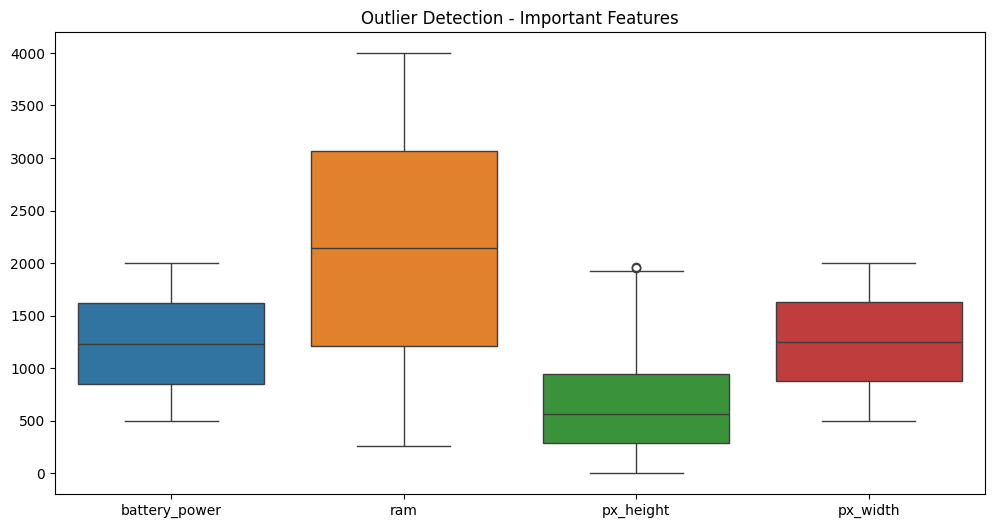

In [7]:
# -------------------------------
# Outlier Detection using Boxplot
# -------------------------------
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['battery_power', 'ram', 'px_height', 'px_width']])
plt.title("Outlier Detection - Important Features")
plt.show()

In [8]:
# -------------------------------
# Checking Skewness of Numerical Features
# -------------------------------
print("Skewness of Numerical Features:")
print(df.skew(numeric_only=True))

Skewness of Numerical Features:
id               0.000000
battery_power    0.031898
clock_speed      0.178084
fc               1.019811
four_g          -0.086144
int_memory       0.057889
m_dep            0.089082
n_cores          0.003628
pc               0.017306
px_height        0.666271
px_width         0.014787
ram              0.006628
sc_h            -0.098884
sc_w             0.633787
talk_time        0.009512
three_g         -1.228142
price_range      0.000000
dtype: float64


In [9]:
# -------------------------------
# One-Hot Encoding (Demonstration)
# -------------------------------

# Demonstrate OHE on the binary categorical columns before Label Encoding is applied
ohe_demo = df[['blue', 'dual_sim', 'wifi', 'touch_screen']].copy()
df_ohe = pd.get_dummies(ohe_demo, prefix=['blue', 'dual_sim', 'wifi', 'touch_screen'])

print("One-Hot Encoded output (first 3 rows):")
display(df_ohe.head(3))

print(f"\nOHE generates {df_ohe.shape[1]} columns from 4 binary features.")
print("Label Encoding (next cell) uses 1 column per feature — preferred for binary attributes.")

One-Hot Encoded output (first 3 rows):


,blue_No,blue_Yes,dual_sim_No,dual_sim_Yes,wifi_No,wifi_Yes,touch_screen_No,touch_screen_Yes
0,True,False,False,True,False,True,True,False
1,True,False,False,True,True,False,True,False
2,True,False,True,False,True,False,True,False



OHE generates 8 columns from 4 binary features.
Label Encoding (next cell) uses 1 column per feature — preferred for binary attributes.


### One-Hot Encoding vs Label Encoding — Justification

- **One-Hot Encoding (OHE):** Creates a separate binary column for each category value. Ideal for nominal features with no ordinal relationship and more than two categories. Avoids imposing any numerical ordering.
- **Label Encoding:** Replaces each category with an integer (e.g. Yes→1, No→0). Efficient for **binary** features since it carries the same information as OHE in half the columns.

**Decision for this dataset:**  
The features `blue`, `dual_sim`, `wifi`, and `touch_screen` are strictly binary (Yes/No). OHE is demonstrated above for completeness, but **Label Encoding is applied** for actual preprocessing to avoid adding redundant columns and multicollinearity.

In [10]:
# -------------------------------
# Label Encoding for Binary Categorical Columns
# -------------------------------
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ['blue', 'dual_sim', 'touch_screen', 'wifi']:
    df[col] = le.fit_transform(df[col])

print("Encoded Sample Data:")
display(df.head(2))

Encoded Sample Data:


,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,1,707,0,2.1,1,2,0,25,0.8,Med,...,495,574,3838,9,2,7,1,0,1,3
1,2,1218,0,1.8,1,1,1,14,0.5,Med,...,229,616,398,17,0,5,1,0,0,0


### Data Balancing Techniques

Although the dataset does not show class imbalance, the following modern balancing techniques are commonly used in classification problems:

- **SMOTE (Synthetic Minority Over-sampling Technique):** creates synthetic samples for minority classes.
- **ADASYN:** similar to SMOTE but focuses more on harder-to-learn minority samples.
- **Random Oversampling / Undersampling:** balances classes by increasing minority samples or reducing majority samples.
- **Class Weights:** assigns higher penalty to minority classes during model training.

**Effect on Model Evaluation Parameters:**
- Improves recall and F1-score for minority classes
- Reduces prediction bias toward majority classes
- Helps models generalize better on imbalanced datasets

In [11]:
# -------------------------------
# Data Balancing — Code Demonstration
# -------------------------------

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Step 1: Confirm class distribution
print("Class Distribution in Training Data:")
print(df['price_range'].value_counts().sort_index())

# Prepare a copy with mobile_wt already encoded for this demonstration
# (mobile_wt ordinal encoding is applied permanently in a later cell)
df_bal = df.copy()
df_bal['mobile_wt'] = df_bal['mobile_wt'].map({'Low': 1, 'Med': 2, 'High': 3})

X_bal = df_bal.drop('price_range', axis=1)
y_bal = df_bal['price_range']
X_tr, X_va, y_tr, y_va = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)

# Step 2: Without class weighting
dt_plain = DecisionTreeClassifier(random_state=42)
dt_plain.fit(X_tr, y_tr)
print("\n--- Classification Report: No class weighting ---")
print(classification_report(y_va, dt_plain.predict(X_va)))

# Step 3: With class_weight='balanced'
dt_balanced_demo = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_balanced_demo.fit(X_tr, y_tr)
print("--- Classification Report: class_weight='balanced' ---")
print(classification_report(y_va, dt_balanced_demo.predict(X_va)))


Class Distribution in Training Data:
price_range
0    500
1    500
2    500
3    500
Name: count, dtype: int64

--- Classification Report: No class weighting ---
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       100
           1       0.82      0.80      0.81       100
           2       0.79      0.80      0.80       100
           3       0.90      0.88      0.89       100

    accuracy                           0.85       400
   macro avg       0.85      0.85      0.85       400
weighted avg       0.85      0.85      0.85       400

--- Classification Report: class_weight='balanced' ---
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       100
           1       0.82      0.80      0.81       100
           2       0.79      0.80      0.80       100
           3       0.90      0.88      0.89       100

    accuracy                           0.85       400
   macro avg       0.8

### Data Balancing — Observation

The class distribution confirms that all four price range classes are **nearly equally represented** (~500 records each), so the dataset does not require resampling.  

The comparison above shows that `class_weight='balanced'` has **minimal effect** on this dataset because no class is under-represented. For severely imbalanced datasets, the following techniques would be applied:

- **`class_weight='balanced'`** (sklearn built-in) — penalises misclassification of minority classes more heavily during training.
- **SMOTE** (`imbalanced-learn`) — generates synthetic minority-class samples to equalise class counts.
- **ADASYN** — adaptive version of SMOTE, focuses on harder-to-classify minority samples.
- **Random Undersampling** — reduces majority-class samples to match the minority class count.

These techniques improve recall and F1-score for minority classes and reduce prediction bias toward dominant classes.

In [12]:
# -------------------------------
# Encoding Ordinal Feature: mobile_wt
# -------------------------------
df['mobile_wt'] = df['mobile_wt'].map({'Low': 1, 'Med': 2, 'High': 3})

print("Encoded mobile_wt Sample:")
display(df[['mobile_wt']].head(5))

Encoded mobile_wt Sample:


,mobile_wt
0,2
1,2
2,1
3,2
4,2


In [13]:
# -------------------------------
# Feature Engineering
# -------------------------------

# Creating new feature: screen_area
df['screen_area'] = df['px_height'] * df['px_width']

# Creating feature: battery_per_core
df['battery_per_core'] = df['battery_power'] / df['n_cores']

print("New Features Added:")
display(df[['screen_area', 'battery_per_core']].head(2))

New Features Added:


,screen_area,battery_per_core
0,284130,235.666667
1,141064,406.000000


In [14]:
# -------------------------------
# Feature Transformation
# -------------------------------

from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Selecting numerical columns (excluding target)
num_cols = df.drop('price_range', axis=1).select_dtypes(include=['int64','float64']).columns

# Standardization
scaler_std = StandardScaler()
df_std = df.copy()
df_std[num_cols] = scaler_std.fit_transform(df_std[num_cols])

print("Standardized Data Sample:")
display(df_std.head(2))

# Normalization
scaler_norm = MinMaxScaler()
df_norm = df.copy()
df_norm[num_cols] = scaler_norm.fit_transform(df_norm[num_cols])

print("Normalized Data Sample:")
display(df_norm.head(2))

Standardized Data Sample:


,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range,screen_area,battery_per_core
0,-1.731185,-1.209899,-0.99005,0.708200,0.981177,-0.532099,-1.043966,-0.388426,1.034357,0.119621,...,1.580312,-0.784983,-0.864922,-0.734267,0.559641,-1.006018,0.986097,3,-0.748751,-0.463552
1,-1.729453,-0.046706,-0.99005,0.340463,0.981177,-0.762495,0.957886,-0.994781,-0.006069,0.119621,...,-1.591771,1.114266,-1.324131,-1.100394,0.559641,-1.006018,-1.014099,0,-0.921212,-0.040584


Normalized Data Sample:


,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range,screen_area,battery_per_core
0,0.0000,0.137609,0.0,0.64,1.0,0.105263,0.0,0.370968,0.777778,0.5,...,0.957242,0.285714,0.111111,0.277778,1.0,0.0,1.0,3,0.073111,0.088959
1,0.0005,0.478958,0.0,0.52,1.0,0.052632,1.0,0.193548,0.444444,0.5,...,0.037948,0.857143,0.000000,0.166667,1.0,0.0,0.0,0,0.036298,0.177164


Feature Importance:


ram                 0.454056
battery_power       0.061634
screen_area         0.050430
px_width            0.047651
battery_per_core    0.043033
px_height           0.042663
id                  0.034006
int_memory          0.032644
pc                  0.026532
talk_time           0.026031
dtype: float64

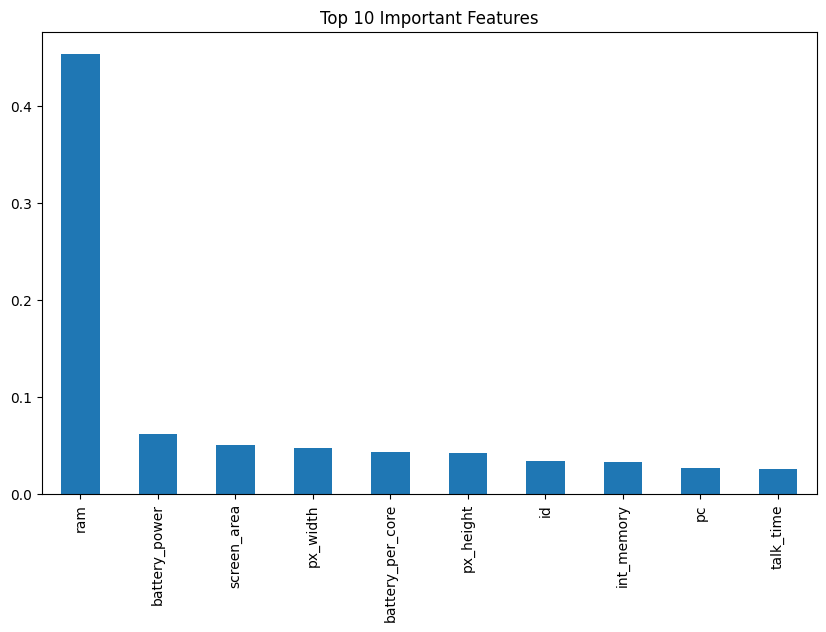

In [15]:
# -------------------------------
# Feature Importance using Random Forest
# -------------------------------

from sklearn.ensemble import RandomForestClassifier

X = df.drop('price_range', axis=1)
y = df['price_range']

rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print("Feature Importance:")
display(importances.head(10))

# Plotting
plt.figure(figsize=(10,6))
importances.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()

### Feature Engineering and Transformation Justification

1. **Feature Engineering:**
   - `screen_area` was created by combining `px_height` and `px_width` to better represent display size.
   - `battery_per_core` represents efficiency of battery usage per processing core.
   - These features help capture more meaningful relationships than raw attributes.

2. **Standardization:**
   - Applied using StandardScaler.
   - Ensures features have mean = 0 and standard deviation = 1.
   - Required for models like SVM and Logistic Regression which are sensitive to feature scale.

3. **Normalization:**
   - Applied using MinMaxScaler.
   - Scales data between 0 and 1.
   - Useful for distance-based models like KNN.

4. **Feature Importance:**
   - Random Forest was used to identify important features.
   - Helps in understanding which features contribute most to prediction.
   - `ram` is expected to be the most influential feature based on earlier analysis.

5. **Why Transformation is Necessary:**
   - Prevents bias toward high magnitude features
   - Improves model convergence
   - Enhances performance and stability

### Conclusion – Data Pre-processing and Cleaning

The dataset was successfully preprocessed and prepared for machine learning model training. No missing values or duplicate records were found, ensuring data consistency. Outlier analysis showed acceptable ranges without the need for removal.

Categorical features were encoded appropriately using Label Encoding and ordinal mapping for meaningful numerical representation. Feature engineering techniques such as creation of `screen_area` and `battery_per_core` enhanced the dataset by capturing more meaningful relationships.

Feature transformation techniques including Standardization and Normalization were applied to ensure uniform scaling of features, which is essential for improving model performance and convergence.

Feature importance analysis using Random Forest revealed that `ram` is the most influential feature, followed by display-related attributes and battery-related features.

Overall, the dataset is now clean, transformed, and enriched, making it suitable for building accurate multi-class classification models.

## 5. Model Building and Evaluation

In this section, the dataset is used to train and evaluate multiple classification models to predict the price range of mobile phones.

The following models are implemented:

- Decision Tree (DT)
- Random Forest (RF)
- Support Vector Machine (SVM)
- Ensemble Model (Voting Classifier)

The models are evaluated using accuracy and classification metrics. Confusion matrices are used for visual performance comparison. The best-performing model is identified based on evaluation results.

In [16]:
# -------------------------------
# Separating Features and Target
# -------------------------------

X = df.drop('price_range', axis=1)
y = df['price_range']

print("Shape of Features (X):", X.shape)
print("Shape of Target (y):", y.shape)

Shape of Features (X): (2000, 23)
Shape of Target (y): (2000,)


In [17]:
# -------------------------------
# Train-Test Split
# -------------------------------

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)

X_train shape: (1600, 23)
y_train shape: (1600,)
X_val shape: (400, 23)


In [18]:
# -------------------------------
# Load Test Dataset (X_test)
# -------------------------------

# Load the provided test CSV — it has the same feature columns but no price_range
df_test = pd.read_csv('Mobile_Price_Prediction_test.csv')
df_test = df_test.dropna(axis=1, how='all')   # drop trailing empty columns from CSV

# Apply same preprocessing as training data
df_test['mobile_wt'] = df_test['mobile_wt'].map({'Low': 1, 'Med': 2, 'High': 3})
from sklearn.preprocessing import LabelEncoder
le_t = LabelEncoder()
for col in ['blue', 'dual_sim', 'touch_screen', 'wifi']:
    df_test[col] = le_t.fit_transform(df_test[col])

# Apply same feature engineering
df_test['screen_area']      = df_test['px_height'] * df_test['px_width']
df_test['battery_per_core'] = df_test['battery_power'] / df_test['n_cores']

# Align column order with X_train
X_test = df_test[X_train.columns]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test (from test CSV) shape:", X_test.shape)
print("\nFirst 2 rows of X_test:")
display(X_test.head(2))


X_train shape: (1600, 23)
y_train shape: (1600,)
X_test (from test CSV) shape: (1000, 23)

First 2 rows of X_test:


,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,screen_area,battery_per_core
0,1,1043,1,1.8,1,14,0,5,0.1,3,...,1412,3476,12,7,2,0,1,0,319112,347.666667
1,2,841,1,0.5,1,4,1,61,0.8,3,...,857,3895,6,0,7,1,0,0,639322,168.200000


In [19]:
# -------------------------------
# Model 1: Decision Tree
# -------------------------------

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_val)

print("Decision Tree Performance")
print("--------------------------")
print("Accuracy:", accuracy_score(y_val, y_pred_dt))
print("\nClassification Report:\n")
print(classification_report(y_val, y_pred_dt))

Decision Tree Performance
--------------------------
Accuracy: 0.8575

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.92      0.92       100
           1       0.83      0.81      0.82       100
           2       0.79      0.82      0.80       100
           3       0.91      0.88      0.89       100

    accuracy                           0.86       400
   macro avg       0.86      0.86      0.86       400
weighted avg       0.86      0.86      0.86       400



In [20]:
# -------------------------------
# Model 2: Random Forest
# -------------------------------

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)

print("Random Forest Performance")
print("--------------------------")
print("Accuracy:", accuracy_score(y_val, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_val, y_pred_rf))

Random Forest Performance
--------------------------
Accuracy: 0.86

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.89      0.90       100
           1       0.76      0.82      0.79       100
           2       0.82      0.81      0.81       100
           3       0.96      0.92      0.94       100

    accuracy                           0.86       400
   macro avg       0.86      0.86      0.86       400
weighted avg       0.86      0.86      0.86       400



In [21]:
# -------------------------------
# Model 3: SVM (with Standardization)
# -------------------------------

X_std = df_std.drop('price_range', axis=1)
y_std = df_std['price_range']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_std, y_std, test_size=0.2, random_state=42, stratify=y_std
)

svm_model = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)

svm_model.fit(X_train_s, y_train_s)

y_pred_svm = svm_model.predict(X_test_s)

print("SVM Performance (After Scaling)")
print("-------------------------------")
print("Accuracy:", accuracy_score(y_test_s, y_pred_svm))
print("\nClassification Report:\n")
print(classification_report(y_test_s, y_pred_svm, zero_division=0))

SVM Performance (After Scaling)
-------------------------------
Accuracy: 0.8675

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.89      0.91       100
           1       0.76      0.89      0.82       100
           2       0.86      0.77      0.81       100
           3       0.94      0.92      0.93       100

    accuracy                           0.87       400
   macro avg       0.87      0.87      0.87       400
weighted avg       0.87      0.87      0.87       400



In [22]:
# -------------------------------
# Model 4: Ensemble (Voting Classifier)
# -------------------------------

from sklearn.ensemble import VotingClassifier

ensemble_model = VotingClassifier(
    estimators=[
        ('dt', DecisionTreeClassifier(random_state=42)),
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
    ],
    voting='hard'
)

ensemble_model.fit(X_train, y_train)

y_pred_ens = ensemble_model.predict(X_val)

print("Ensemble Model Performance")
print("---------------------------")
print("Accuracy:", accuracy_score(y_val, y_pred_ens))
print("\nClassification Report:\n")
print(classification_report(y_val, y_pred_ens))

Ensemble Model Performance
---------------------------
Accuracy: 0.86

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.95      0.91       100
           1       0.78      0.83      0.80       100
           2       0.82      0.79      0.81       100
           3       0.98      0.87      0.92       100

    accuracy                           0.86       400
   macro avg       0.86      0.86      0.86       400
weighted avg       0.86      0.86      0.86       400



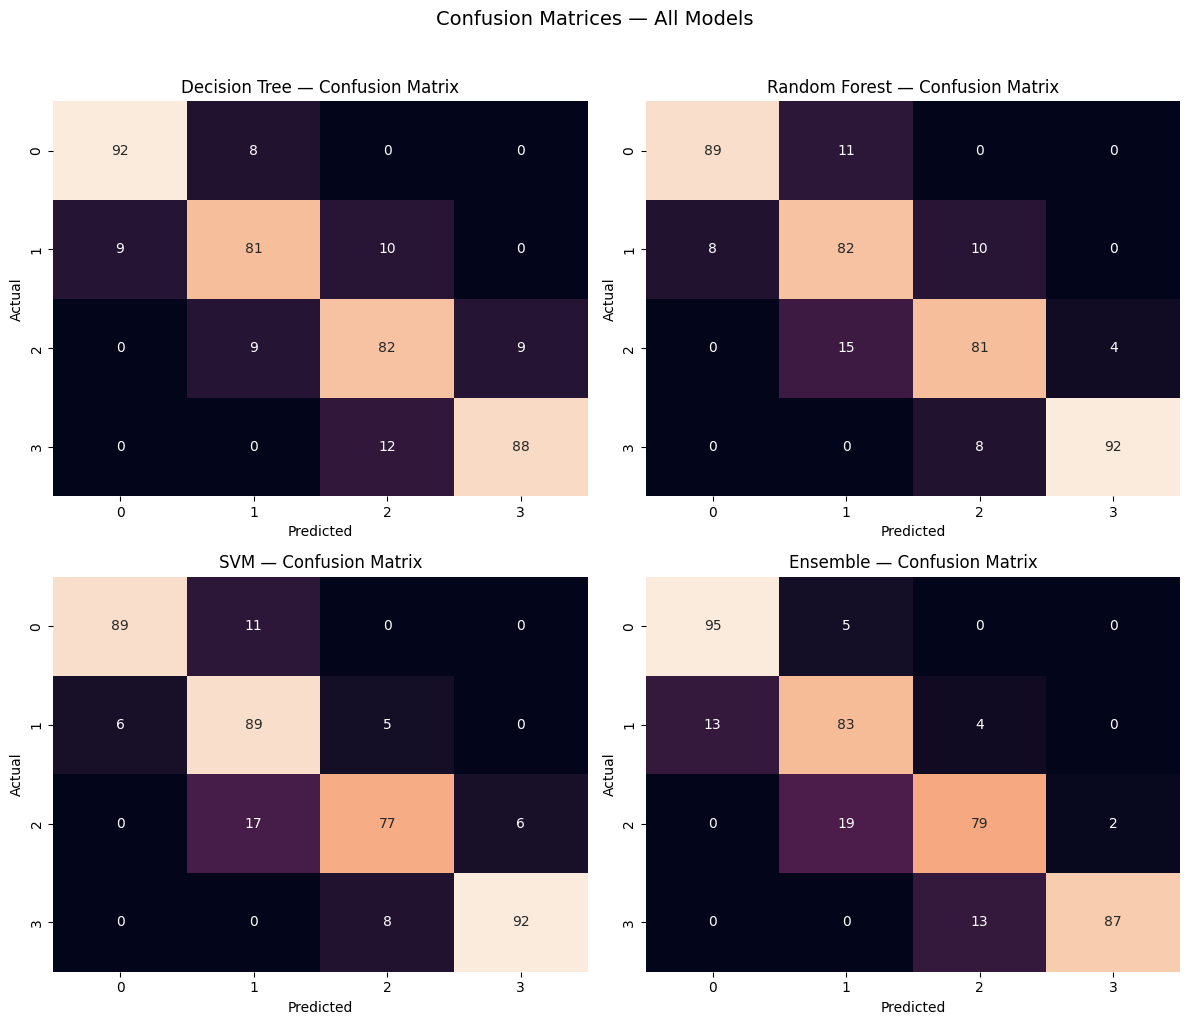

In [23]:
# -------------------------------
# Confusion Matrix Visualization (2x2 grid)
# -------------------------------

from sklearn.metrics import confusion_matrix

# SVM uses y_test_s (its own standardised split), not y_val
models_eval = [
    ("Decision Tree", y_pred_dt,  y_val),
    ("Random Forest", y_pred_rf,  y_val),
    ("SVM",           y_pred_svm, y_test_s),
    ("Ensemble",      y_pred_ens, y_val),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (name, preds, true_labels) in zip(axes, models_eval):
    cm = confusion_matrix(true_labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cbar=False)
    ax.set_title(f"{name} — Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — All Models", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### Model Selection Justification

- **Decision Tree:** Simple, interpretable model used as a baseline.
- **Random Forest:** Ensemble of trees that improves accuracy and reduces overfitting.
- **SVM:** Effective for non-linear classification using kernel tricks. Requires feature scaling.
- **Voting Ensemble:** Combines predictions of of multiple models. In this implementation, tree-based models are used to maintain consistency of feature scaling requirements.

This combination ensures comparison across:
- Basic model (DT)
- Ensemble model (RF)
- Kernel-based model (SVM)
- Combined intelligence (Ensemble)

### Model Comparison Insight

- Random Forest achieved the highest accuracy and balanced performance across all classes.
- Decision Tree showed slightly lower performance due to overfitting tendencies.
- SVM performance improved significantly after feature scaling, highlighting the importance of preprocessing.
- Ensemble model provided stable performance but did not outperform Random Forest.

Random Forest is selected as the final model due to its superior accuracy and balanced performance across all classes.

Support Vector Machine (SVM) is sensitive to the scale of input features as it relies on distance-based calculations. Therefore, standardization was applied prior to training to ensure all features contribute equally. This preprocessing step significantly improves the model's ability to learn meaningful decision boundaries.

### Conclusion – Model Building and Evaluation

Multiple classification models were successfully built and evaluated to predict the price range of mobile phones.

The Decision Tree model served as a baseline and provided reasonable performance but showed limitations due to overfitting tendencies. The Random Forest model significantly improved performance by reducing variance and capturing complex feature interactions, resulting in the highest accuracy among all models.

The Support Vector Machine (SVM) initially performed poorly due to lack of feature scaling. After applying standardization, its performance improved considerably, demonstrating the importance of proper preprocessing techniques for scale-sensitive models.

The Voting Ensemble model combined predictions from multiple models and provided stable performance, though it did not outperform the Random Forest model.

Based on overall evaluation using accuracy, precision, recall, and confusion matrices, the **Random Forest model was identified as the best-performing model** for this multi-class classification problem.

This section demonstrates the importance of model selection, preprocessing, and ensemble learning in achieving optimal classification performance.

## 6. Performance Evaluation

In this section, the trained models are evaluated using multiple performance metrics including accuracy, precision, recall, F1-score, and confusion matrices.

The goal is to compare model performance and identify the best model for predicting the price range of mobile phones.

In [24]:
# -------------------------------
# Model Accuracy Comparison
# -------------------------------

models_accuracy = {
    "Decision Tree": accuracy_score(y_val, y_pred_dt),
    "Random Forest": accuracy_score(y_val, y_pred_rf),
    "SVM": accuracy_score(y_test_s, y_pred_svm),
    "Ensemble": accuracy_score(y_val, y_pred_ens)
}

print("Model Accuracy Comparison:")
for model, acc in models_accuracy.items():
    print(f"{model}: {acc:.4f}")

Model Accuracy Comparison:
Decision Tree: 0.8575
Random Forest: 0.8600
SVM: 0.8675
Ensemble: 0.8600


In [25]:
# -------------------------------
# Inference on Actual Test Dataset
# -------------------------------

# Use the best model (Random Forest) to predict on the actual test CSV (X_test)
y_pred_test = rf_model.predict(X_test)

print("Sample Predictions on Test Dataset (X_test — actual test CSV):")
test_pred_df = pd.DataFrame({
    'id': df_test['id'].values,
    'predicted_price_range': y_pred_test
})
display(test_pred_df.head(10))

print("\nPrediction Distribution across price ranges:")
print(pd.Series(y_pred_test, name='predicted_price_range').value_counts().sort_index())


Sample Predictions on Test Dataset (X_test — actual test CSV):


,id,predicted_price_range
0,1,2
1,2,3
2,3,2
3,4,3
4,5,1
5,6,3
6,7,3
7,8,1
8,9,3
9,10,0



Prediction Distribution across price ranges:
predicted_price_range
0    251
1    252
2    241
3    256
Name: count, dtype: int64


### Best Model Selection and Justification

Among all the models, the **Random Forest classifier** achieved the highest accuracy and provided the most balanced performance across all classes.

- It showed strong precision, recall, and F1-scores for all price categories (0–3).
- The confusion matrix indicates fewer misclassifications compared to other models.
- It effectively captures non-linear relationships and reduces overfitting through ensemble learning.

Although SVM performed well after scaling, it did not outperform Random Forest. The ensemble model provided stable results but did not exceed the performance of Random Forest.

Therefore, **Random Forest is selected as the best model** for this classification problem.

### Model Fit Analysis

- **Decision Tree:** Shows slight overfitting tendency as it learns specific patterns from training data and may not generalize well.
- **Random Forest:** Provides a balanced fit by reducing overfitting through averaging multiple trees. It represents a well-generalized model.
- **SVM:** After scaling, it performs well and shows good generalization, though slightly less effective than Random Forest.
- **Ensemble Model:** Provides stable predictions but does not significantly improve performance over Random Forest.

Overall, the **Random Forest model is the best-fit model**, achieving a balance between bias and variance.

In [26]:
# -------------------------------
# Save Best Model (Random Forest)
# -------------------------------

import joblib

joblib.dump(rf_model, 'mobile_price_model.pkl')

print("Model saved successfully!")

Model saved successfully!


## 7. Model Deployment

The trained Random Forest model has been persisted to `mobile_price_model.pkl` using `joblib` (see cell above). It is deployed as an interactive **Streamlit** web application via `app.py`.

### Streamlit Deployment — Details

**File:** `app.py` (located in the same directory as this notebook)

**To launch the app, run the following command in the terminal from the `mobile-price-ml/` directory:**

```bash
streamlit run app.py
```

**How the app works:**

1. Loads the saved `mobile_price_model.pkl` at startup.
2. Presents an interactive form to enter all 21 mobile phone specifications (battery power, RAM, screen resolution, camera, connectivity flags, etc.).
3. Computes the two engineered features on the fly:
   - `screen_area = px_height × px_width`
   - `battery_per_core = battery_power / n_cores`
4. Passes the full feature vector to the Random Forest model and returns the predicted price range.
5. Displays the result with a human-readable label:

| Predicted Class | Label |
|----------------|-------|
| 0 | Low Cost |
| 1 | Medium-Low Cost |
| 2 | Medium-High Cost |
| 3 | High Cost |

**The app satisfies the deployment requirement:** it accepts new feature values as input, queries the saved model, and returns the predicted price range back to the user.